<a href="https://colab.research.google.com/github/zahira456/Zahira-Nur-Asyifa_2411532015_ML2526/blob/main/Praktikum1/MultipleLinierRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler

housing = fetch_california_housing()
df = pd.DataFrame(data = housing.data, columns = housing.feature_names)
df['MedHouseValue'] = pd.Series(housing.target)

targets=df['MedHouseValue']
inputs=df.drop('MedHouseValue',axis=1)
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [3]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.3, random_state=1)
print("Shape data latih:", inputs_train.shape, targets_train.shape)
print("Shape data uji:", inputs_test.shape, targets_test.shape)

Shape data latih: (14448, 8) (14448,)
Shape data uji: (6192, 8) (6192,)


In [4]:
scaler = MinMaxScaler()
inputs_train = scaler.fit_transform(inputs_train)
inputs_test = scaler.transform(inputs_test)
print(inputs_test)

[[1.89659453e-01 7.45098039e-01 2.59249620e-02 ... 8.26699958e-04
  1.61530287e-01 5.94594595e-01]
 [1.01964111e-01 7.05882353e-01 2.93658328e-02 ... 1.49655077e-03
  4.50584485e-01 4.52452452e-01]
 [2.42293210e-01 8.82352941e-01 2.57625553e-02 ... 2.43712035e-03
  5.51540914e-01 1.88188188e-01]
 ...
 [1.43901463e-01 9.01960784e-01 2.71911561e-02 ... 1.63065424e-03
  5.92986185e-01 2.05205205e-01]
 [1.45508338e-01 2.35294118e-01 2.97484189e-02 ... 1.59782455e-03
  5.87672689e-01 2.06206206e-01]
 [8.33367816e-02 5.49019608e-01 1.45501245e-02 ... 1.74904890e-03
  1.65781084e-01 6.00600601e-01]]


Intercept: 3.721516132506502
Slope:
MedInc: 6.395139137402347
HouseAge: 0.4940889262178403
AveRooms: -14.780759189088904
AveBedrms: 20.983911279487202
Population: -0.20032070194689763
AveOccup: -4.085519367210566
Latitude: -3.982145612940185
Longitude: -4.374609574673599
MSE: 0.5296293151408232
R2: 0.597142973735963


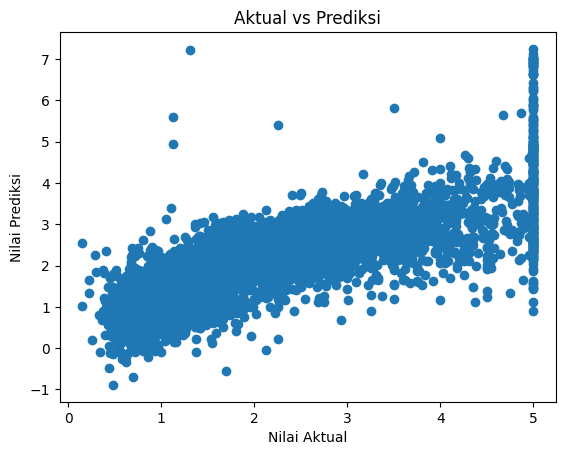

In [5]:
model = LinearRegression()
model.fit(inputs_train, targets_train)

print("Intercept:", model.intercept_)
print("Slope:")
for name, coef in zip(inputs.columns, model.coef_):
    print(f"{name}: {coef}")

pred = model.predict(inputs_test)

mse = mean_squared_error(targets_test, pred)
r2 = model.score(inputs_test, targets_test)

print("MSE:", mse)
print("R2:", r2)

plt.scatter(targets_test, pred)
plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")
plt.title("Aktual vs Prediksi")
plt.show()

In [7]:
import pickle

filename = 'finalized_model.sav'
pickle.dump(model, open(filename, 'wb'))